In [84]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.graphics.tsaplots as tsa_plots
from statsmodels.tsa.arima_model import ARIMA
import seaborn as sns
import requests
from bs4 import BeautifulSoup

#### 1 Month T-Bills data

we will get the 1M T-Bills data from Swaminathan (Treasury team) over Outlook mail on monthly basis.

In [85]:
datas= pd.read_excel(r"D:\TASK\CP rates\1M T Bill\1Month T bills.xlsx")
print(datas.shape)
datas.head(5)

(3874, 2)


,Date,CutOff_Yield
0,2010-01-01,3.1673
1,2010-01-04,3.0964
2,2010-01-05,3.1614
3,2010-01-06,3.2286
4,2010-01-07,3.3023


In [86]:
datas['Year']= datas['Date'].dt.year
datas= datas.set_index('Date')
datas.head(3)

,CutOff_Yield,Year
Date,,
2010-01-01,3.1673,2010
2010-01-04,3.0964,2010
2010-01-05,3.1614,2010


### US- Federal Reserve Rate

In [87]:

import requests
from bs4 import BeautifulSoup

def fetch_fomc_table_bs4(url: str):
    headers = {
        "User-Agent": (
            "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
            "AppleWebKit/537.36 (KHTML, like Gecko) "
            "Chrome/120.0.0.0 Safari/537.36"
        ),
        "Accept-Language": "en-US,en;q=0.9",
        "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8",
    }

    with requests.Session() as s:
        s.headers.update(headers)
        try:
            resp = s.get(url, timeout=15)
            resp.raise_for_status()  # raises HTTPError for 4xx/5xx
        except requests.exceptions.RequestException as e:
            raise RuntimeError(f"Network/HTTP error fetching page: {e}")

        soup = BeautifulSoup(resp.content, "html.parser")

        # Some Wikipedia pages have multiple 'wikitable sortable' tables.
        tables = soup.find_all("table", class_="wikitable sortable")
        if not tables:
            # try plain 'wikitable'
            tables = soup.find_all("table", class_="wikitable")
        if not tables:
            raise RuntimeError("No 'wikitable' found on the page.")

        # pick the first table; adapt if you need a specific one
        table = tables[0]

        # Extract headers (optional but helpful)
        header_cells = table.find_all("tr")[0].find_all(["th", "td"])
        headers = [hc.get_text(strip=True) for hc in header_cells]

        data = []
        for tr in table.find_all("tr")[1:]:  # skip header row
            tds = tr.find_all("td")
            if not tds:
                continue
            row = [td.get_text(strip=True) for td in tds]
            # skip empty rows
            if any(cell for cell in row):
                data.append(row)

        return headers, data


if __name__ == "__main__":
    url = "https://en.wikipedia.org/wiki/History_of_Federal_Open_Market_Committee_actions"
    try:
        headers, data = fetch_fomc_table_bs4(url)
        print("Columns:", headers)
        print(f"Rows extracted: {len(data)}")
        # Example: print first 5 rows
        for r in data[:5]:
            print(r)
    except Exception as e:
        print(f"Error: {e}")


Columns: ['Date', 'Fed. Funds Rate', 'Discount Rate', 'Votes', 'Notes']
Rows extracted: 143
['December 10, 2025', '3.50%–3.75%', '3.75%', '9–3', 'Stephen Miranpreferred a higher 50-basis-point cut, whileAustan GoolsbeeandJeffrey Schmidpreferred to maintain the rate.Official statement']
['October 29, 2025', '3.75%–4.00%', '4.00%', '10–2', 'Stephen Miranpreferred a higher 50-basis-point cut, whileJeffrey Schmidpreferred to maintain the rate.Official statement']
['September 17, 2025', '4.00%–4.25%', '4.25%', '11–1', 'Stephen Miranpreferred a higher 50-basis-point cut.Official statement']
['July 30, 2025', '4.25%–4.50%', '4.50%', '9–2', 'Michelle BowmanandChristopher Wallerpreferred a 25-basis-point cut.Official statement']
['June 18, 2025', '4.25%–4.50%', '4.50%', '12–0', 'Official statement']


In [88]:

import re
import pandas as pd
import numpy as np

# Assuming these variables are already defined from your working scraping function:
# headers, data = fetch_fomc_table_bs4(url)

# Build the DataFrame with your desired column names
fed = pd.DataFrame(
    data,
    columns=['Date', 'Fed_Funds_Rate', 'Fed_Reserve_Rate', 'Votes', 'Notes']
)

# Keep only Date and Fed_Reserve_Rate
fed = fed[['Date', 'Fed_Reserve_Rate']].copy()

# Reset index
fed = fed.reset_index(drop=True)

# Convert Date to datetime (coerce invalid formats to NaT)
fed['Date'] = pd.to_datetime(fed['Date'], errors='coerce')

# Clean Fed_Reserve_Rate text:
# 1) Remove footnote brackets like [a], [1], etc.
# 2) Normalize unicode en dashes to hyphens for splitting ranges
# 3) Remove '%' symbols and extra spaces
def clean_rate_text(x: str) -> str:
    if pd.isna(x):
        return x
    x = re.sub(r'\[.*?\]', '', x)         # remove bracketed notes
    x = x.replace('–', '-')               # en dash to hyphen
    x = x.replace('−', '-')               # minus sign to hyphen (just in case)
    x = x.replace('%', '')                # remove percent sign
    return x.strip()

fed['Fed_Reserve_Rate'] = fed['Fed_Reserve_Rate'].astype(str).apply(clean_rate_text)

# Convert to float:
# - If it's a range like "5.25-5.50", take the midpoint.
# - If it's a single number like "5.50", parse directly.
# - If unparsable (e.g., "N/A"), return NaN.
def parse_rate_to_float(x: str) -> float:
    if x is None or x == '' or x.lower() in {'na', 'n/a', 'nan'}:
        return np.nan
    # Range detection (two numbers separated by '-')
    if '-' in x:
        parts = [p.strip() for p in x.split('-') if p.strip() != '']
        try:
            nums = [float(p) for p in parts]
            if len(nums) == 2:
                return (nums[0] + nums[1]) / 2.0
            # If more than two parts, fallback to first parsable
            return float(nums[0]) if nums else np.nan
        except ValueError:
            return np.nan
    # Single value
    try:
        return float(x)
    except ValueError:
        return np.nan

fed['Fed_Reserve_Rate'] = fed['Fed_Reserve_Rate'].apply(parse_rate_to_float).astype('float64')

# Show the first few rows
print(fed.head())


        Date  Fed_Reserve_Rate
0 2025-12-10              3.75
1 2025-10-29              4.00
2 2025-09-17              4.25
3 2025-07-30              4.50
4 2025-06-18              4.50


In [ ]:
# '''Load this cell if you can't web scrap the fed reserve data from the wikipedia. 
# you have to collect the fed data manually from below webiste in excel load this cell.
# https://en.wikipedia.org/wiki/History_of_Federal_Open_Market_Committee_actions'''

# fed= pd.read_excel(r"D:\TASK\CP rates\Cogencis data\US Fed Reserve rate.xlsx")
# fed=fed[['Date','Discount Rate']]
# fed['Discount Rate']= fed['Discount Rate']*100
# fed=fed.reset_index(drop=True)
# fed['Date']=pd.to_datetime(fed['Date'])
# #fed['Discount Rate']= fed['Discount Rate'].str.replace("%","")
# #fed['Discount Rate']= fed['Discount Rate'].apply(lambda x: re.sub(r'\[.*?\]', '', x))
# fed['Discount Rate']= fed['Discount Rate'].astype('float64')
# fed.rename(columns={'Discount Rate':'Fed_Reserve_Rate'}, inplace=True)
# fed.head()

In [90]:
# This cell is to convert the fed reserve data to daily format

fed= fed.sort_values('Date', ascending=True)
fed= fed.set_index('Date')
fed_daily= fed.resample('D').ffill()
fed_daily.tail()

,Fed_Reserve_Rate
Date,
2025-12-06,4.00
2025-12-07,4.00
2025-12-08,4.00
2025-12-09,4.00
2025-12-10,3.75


In [91]:
# In this cell appending the fed data into base dataframe (cut-off yield)

base= pd.merge(datas, fed_daily, left_index=True, right_index=True, how='left')
base= base.ffill()
print(base.shape)
base.head(3)

(3874, 3)


,CutOff_Yield,Year,Fed_Reserve_Rate
Date,,,
2010-01-01,3.1673,2010,0.5
2010-01-04,3.0964,2010,0.5
2010-01-05,3.1614,2010,0.5


In [92]:
base.tail(3)

,CutOff_Yield,Year,Fed_Reserve_Rate
Date,,,
2026-01-03,5.25,2026,3.75
2026-01-04,5.25,2026,3.75
2026-01-05,5.21,2026,3.75


### Monetory Rates- Bank rates, MSF & SDF

#### Path to get the data from RBI website

Home > Publication --> Handbook of Statistics on the Indian Economy --> Part I: Annual series --> Money and Banking -->
Major Monetary Policy Rates and Reserve Requirements - Bank Rate, LAF (Repo, Reverse Repo and MSF) Rates, CRR & SLR

In [93]:
monetory= pd.read_excel(r"D:\TASK\CP rates\Cogencis data\Major Monetary Policy Rates.xlsx")
monetry=monetory.iloc[7:150,1:]
monetry.rename(columns={'Unnamed: 1':'Date', 'Unnamed: 2':'Bank Rate', 'Unnamed: 3':'Repo',
                        'Unnamed: 4':'Reverse Repo', 'Unnamed: 5':'Standing Deposit Facility Rate', 
                        'Unnamed: 6':'Marginal Standing Facility Rate', 'Unnamed: 7':'Cash Reserve Ratio',
                        'Unnamed: 8':'Statutory Liquidity Ratio'}, inplace=True)

monetory.head()

d:\ML_Proj\PDF_ChatBot-using_GeminiPro\vevn\lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8
0,NaN,Major Monetary Policy Rates and Reserve Requir...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,(Per cent),NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,Effective Date\n,Bank Rate,Fix Range LAF Rates,NaN,Standing Deposit Facility (SDF) Rate,Marginal Standing Facility (MSF) Rate,Cash Reserve Ratio (CRR),Statutory Liquidity Ratio (SLR)


In [94]:
# In this cell done the sorting and filling the null values in df with previous values

monetry= monetry.sort_values(by='Date',ascending=True)
monetry= monetry.replace('-',np.nan)
monetry= monetry.ffill()
monetry= monetry.bfill()
monetry.head()

C:\Users\manirathinams\AppData\Local\Temp\ipykernel_5060\422952886.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  monetry= monetry.replace('-',np.nan)


,Date,Bank Rate,Repo,Reverse Repo,Standing Deposit Facility Rate,Marginal Standing Facility Rate,Cash Reserve Ratio,Statutory Liquidity Ratio
149,2001-10-23,6.5,8.0,6.0,3.75,8.25,5.75,24.0
148,2001-11-03,6.5,8.0,6.0,3.75,8.25,5.75,24.0
147,2001-12-29,6.5,8.0,6.0,3.75,8.25,5.5,24.0
146,2002-03-05,6.5,8.0,6.0,3.75,8.25,5.5,24.0
145,2002-03-28,6.5,8.0,6.0,3.75,8.25,5.5,24.0


In [95]:
monetry.info()

<class 'pandas.core.frame.DataFrame'>
Index: 143 entries, 149 to 7
Data columns (total 8 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   Date                             143 non-null    datetime64[ns]
 1   Bank Rate                        143 non-null    float64       
 2   Repo                             143 non-null    float64       
 3   Reverse Repo                     143 non-null    float64       
 4   Standing Deposit Facility Rate   143 non-null    float64       
 5   Marginal Standing Facility Rate  143 non-null    float64       
 6   Cash Reserve Ratio               143 non-null    object        
 7   Statutory Liquidity Ratio        143 non-null    float64       
dtypes: datetime64[ns](1), float64(6), object(1)
memory usage: 10.1+ KB


In [96]:
monetry['Cash Reserve Ratio']= monetry['Cash Reserve Ratio'].astype('float')
monetry['Date']=pd.to_datetime(monetry['Date'],format="%d-%m-%Y")
monetry[monetry.duplicated()==True]

# In this cell converting the data into daily format 
monetry=monetry.drop_duplicates()
monetry1= monetry.set_index('Date')
monetry_d= monetry1.resample('D').ffill()
monetry_d.head(3)

,Bank Rate,Repo,Reverse Repo,Standing Deposit Facility Rate,Marginal Standing Facility Rate,Cash Reserve Ratio,Statutory Liquidity Ratio
Date,,,,,,,
2001-10-23,6.5,8.0,6.0,3.75,8.25,5.75,24.0
2001-10-24,6.5,8.0,6.0,3.75,8.25,5.75,24.0
2001-10-25,6.5,8.0,6.0,3.75,8.25,5.75,24.0


In [97]:
monetry_d.tail(3)

,Bank Rate,Repo,Reverse Repo,Standing Deposit Facility Rate,Marginal Standing Facility Rate,Cash Reserve Ratio,Statutory Liquidity Ratio
Date,,,,,,,
2025-12-03,5.75,5.50,3.35,5.25,5.75,3.0,18.0
2025-12-04,5.75,5.50,3.35,5.25,5.75,3.0,18.0
2025-12-05,5.50,5.25,3.35,5.00,5.50,3.0,18.0


In [98]:
## In this cell appending the monetry data into base dataframe cut-off yield.

dfrs= pd.merge(base, monetry_d, left_index=True, right_index=True, how='left')
print(dfrs.shape)
dfrs.head(2)

(3874, 10)


,CutOff_Yield,Year,Fed_Reserve_Rate,Bank Rate,Repo,Reverse Repo,Standing Deposit Facility Rate,Marginal Standing Facility Rate,Cash Reserve Ratio,Statutory Liquidity Ratio
Date,,,,,,,,,,
2010-01-01,3.1673,2010,0.5,6.0,4.75,3.25,3.75,8.25,5.0,25.0
2010-01-04,3.0964,2010,0.5,6.0,4.75,3.25,3.75,8.25,5.0,25.0


In [99]:
# Reset index to convert date index column to a normal column
dfrs.reset_index(inplace=True)
dfrs.rename(columns={'index': 'date'}, inplace=True)
dfrs.head(3)

,Date,CutOff_Yield,Year,Fed_Reserve_Rate,Bank Rate,Repo,Reverse Repo,Standing Deposit Facility Rate,Marginal Standing Facility Rate,Cash Reserve Ratio,Statutory Liquidity Ratio
0,2010-01-01,3.1673,2010,0.5,6.0,4.75,3.25,3.75,8.25,5.0,25.0
1,2010-01-04,3.0964,2010,0.5,6.0,4.75,3.25,3.75,8.25,5.0,25.0
2,2010-01-05,3.1614,2010,0.5,6.0,4.75,3.25,3.75,8.25,5.0,25.0


### Adding LAF weekly Data

we will get this LAF weekly data from madhumitha

In [100]:
laf_df= pd.read_excel(r"D:\TASK\CP rates\Cogencis data\LAF Weekly.xlsx")
print(laf_df.shape)
laf_df.head(3)

(1340, 43)


,Liquidity Adjustment Facility and Open Market Operations of RBI,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 33,Unnamed: 34,Unnamed: 35,Unnamed: 36,Unnamed: 37,Unnamed: 38,Unnamed: 39,Unnamed: 40,Unnamed: 41,Unnamed: 42
0,Year,Frequency,Net liquidity injected (outstanding including ...,Repo : End-period rate,Repo : Turnover,Repo : Average daily turnover,Repo : Outstanding turnover,Overnight repo - variable rate : Cut off rate,Overnight repo - variable rate : Turnover,Overnight repo - variable rate : Outstanding t...,...,Standing Liquidity Facility : Average daily tu...,Standing Liquidity Facility : Outstanding turn...,Special Liquidity Facility for Mutual Funds (S...,Special Liquidity Scheme for NBFCs/HFCs,Special Long - Term Repo Operations for Small ...,Special Reverse Repo,Market Stabilisation Scheme (MSS),Open Market Operations : Net sales,Open Market Operations : Sale,Open Market Operations : Purchase
1,NaN,NaN,Rs. Million,%,Rs. Million,Rs. Million,Rs. Million,%,Rs. Million,Rs. Million,...,Rs. Million,Rs. Million,Rs. Million,Rs. Million,Rs. Million,Rs. Million,Rs. Million,Rs. Million,Rs. Million,Rs. Million
2,20000407,W,-188800,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0


In [101]:
# In this cell selecting columns and forwardfill the null values and do cleaning

laf= laf_df.iloc[2:,[0,2,7,17,10,20]]
laf.rename(columns={laf.columns[0]: 'Date', laf.columns[1]: 'Net Liquidity',
                    laf.columns[2]: 'Overnight Repo Cut off', laf.columns[3]: 'Overnight Rev Repo Cut off',
                    laf.columns[4]: 'Term Repo Cut off', laf.columns[5]: 'Term Rev Repo Cut off'}, inplace=True)

laf["Overnight Repo Cut off"]=laf["Overnight Repo Cut off"].ffill()
laf["Overnight Repo Cut off"]=laf["Overnight Repo Cut off"].bfill()

laf["Overnight Rev Repo Cut off"]=laf["Overnight Rev Repo Cut off"].ffill()
laf["Overnight Rev Repo Cut off"]=laf["Overnight Rev Repo Cut off"].bfill()

laf["Term Repo Cut off"]=laf["Term Repo Cut off"].ffill()
laf["Term Repo Cut off"]=laf["Term Repo Cut off"].bfill()

laf["Term Rev Repo Cut off"]=laf["Term Rev Repo Cut off"].ffill()
laf["Term Rev Repo Cut off"]=laf["Term Rev Repo Cut off"].bfill()

laf['Date']= laf.apply(lambda row: str(row['Date'])[0:4]+'-'+str(row['Date'])[4:6]+'-'+str(row['Date'])[6:], axis=1)
laf= laf.loc[laf['Date']> '2009-12-31']
laf= laf.sort_values('Date', ascending=True)
print(laf.shape)
laf.head(5)

(836, 6)


C:\Users\manirathinams\AppData\Local\Temp\ipykernel_5060\1412068673.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  laf["Overnight Repo Cut off"]=laf["Overnight Repo Cut off"].ffill()
C:\Users\manirathinams\AppData\Local\Temp\ipykernel_5060\1412068673.py:11: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  laf["Overnight Rev Repo Cut off"]=laf["Overnight Rev Repo Cut off"].ffill()
C:\Users\manirathinams\AppData\Local\Temp\ipykernel_5060\1412068673.py:14: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will cha

,Date,Net Liquidity,Overnight Repo Cut off,Overnight Rev Repo Cut off,Term Repo Cut off,Term Rev Repo Cut off
504,2010-01-01,-882000,8.01,7.99,8.8,7.99
505,2010-01-08,-871300,8.01,7.99,8.8,7.99
506,2010-01-15,-807800,8.01,7.99,8.8,7.99
507,2010-01-22,-703300,8.01,7.99,8.8,7.99
508,2010-01-29,-882900,8.01,7.99,8.8,7.99


In [102]:
## Merging the LAF data with Base dataframe

dfrs['Date']= pd.to_datetime(dfrs['Date'], format='%Y-%m-%d')
laf['Date']= pd.to_datetime(laf['Date'], format='%Y-%m-%d')
laf.set_index('Date', inplace=True)
laf_d= laf.resample('D').ffill()
laf_d.reset_index(inplace=True)

dfs= dfrs.merge(laf_d, how='left', on='Date')
dfs.tail()

,Date,CutOff_Yield,Year,Fed_Reserve_Rate,Bank Rate,Repo,Reverse Repo,Standing Deposit Facility Rate,Marginal Standing Facility Rate,Cash Reserve Ratio,Statutory Liquidity Ratio,Net Liquidity,Overnight Repo Cut off,Overnight Rev Repo Cut off,Term Repo Cut off,Term Rev Repo Cut off
3869,2026-01-01,5.22,2026,3.75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1403542.3,5.26,5.49,5.26,5.24
3870,2026-01-02,5.25,2026,3.75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-872423,5.26,5.49,5.26,5.24
3871,2026-01-03,5.25,2026,3.75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3872,2026-01-04,5.25,2026,3.75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3873,2026-01-05,5.21,2026,3.75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Adding CPI-Inflation Data (CPI- Consumer Price Index)
We will get this data from Madhumitha, CPI data is monthly data

In [ ]:
cpi_df= pd.read_excel(r"D:\TASK\CP rates\Cogencis data\CPI Inflation Monthly data.xlsx")
print(cpi_df.shape)
cpi_df.head(3)

(345, 23)


,"Consumer Price Index (CPI): Combined, Urban and Rural: General Index, Groups and Subgroups : Base Year 2012 : Index numbers",Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22
0,Year,Frequency,General Index,General Index,General Index,Food and beverages,Food and beverages,Food and beverages,"Pan, tobacco and intoxicants","Pan, tobacco and intoxicants",...,Clothing & footwear,Housing,Housing,Housing,Fuel & light,Fuel & light,Fuel & light,Miscellaneous,Miscellaneous,Miscellaneous
1,NaN,NaN,Combined,Urban,Rural,Combined,Urban,Rural,Combined,Urban,...,Rural,Combined,Urban,Rural,Combined,Urban,Rural,Combined,Urban,Rural
2,Weight,NaN,100,100,100,45.86,36.29,54.18,2.38,1.36,...,7.36,10.07,21.67,0,6.84,5.58,7.94,28.32,29.53,27.26


In [104]:
# In this cell doing data cleaning and fill the null values with forwardfill

cpi= cpi_df.iloc[3:,[0,1,2]]
cpi.rename(columns={cpi.columns[0]: 'Date', cpi.columns[1]: 'Freq', cpi.columns[2]: 'CPI Inflation'}, inplace=True)
cpi= cpi.loc[cpi['Freq']=='M']
cpi= cpi.drop('Freq', axis=1)

cpi["CPI Inflation"]= cpi["CPI Inflation"].ffill()
cpi["CPI Inflation"]= cpi["CPI Inflation"].bfill()

cpi['Date']= cpi.apply(lambda row: str(row['Date'])[0:4]+'-'+str(row['Date'])[4:6]+'-'+str(row['Date'])[6:], axis=1)
cpi= cpi.loc[cpi['Date']> '2009-12-31']
cpi= cpi.sort_values('Date', ascending=True)
print(cpi.shape)
cpi.head(5)

(179, 2)


C:\Users\manirathinams\AppData\Local\Temp\ipykernel_5060\999881680.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cpi["CPI Inflation"]= cpi["CPI Inflation"].ffill()


,Date,CPI Inflation
3,2011-01-31,89.5
4,2011-02-28,88.4
5,2011-03-31,88.4
6,2011-04-30,89.1
7,2011-05-31,89.8


In [105]:
cpi['Date']= pd.to_datetime(cpi['Date'], format='%Y-%m-%d')
# adding the month_year column in cpi based on date column
cpi['month_year'] = cpi['Date'].dt.strftime('%b-%Y')
cpi.head()

# adding the month_year column in base dataframe based on date column
dfs['month_year'] = dfs['Date'].dt.strftime('%b-%Y')

# Joining the CPI data with Base dataframe based on month-year column
dfs= dfs.merge(cpi[['CPI Inflation','month_year']], how='left', on='month_year')
dfs= dfs.loc[dfs['Date']> '2010-12-31']

# drop the month-year column
#dfs= dfs.drop('month_year', axis=1)
dfs= dfs.ffill()
print(dfs.shape)
dfs.head()

(3629, 18)


C:\Users\manirathinams\AppData\Local\Temp\ipykernel_5060\2014517096.py:15: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dfs= dfs.ffill()


,Date,CutOff_Yield,Year,Fed_Reserve_Rate,Bank Rate,Repo,Reverse Repo,Standing Deposit Facility Rate,Marginal Standing Facility Rate,Cash Reserve Ratio,Statutory Liquidity Ratio,Net Liquidity,Overnight Repo Cut off,Overnight Rev Repo Cut off,Term Repo Cut off,Term Rev Repo Cut off,month_year,CPI Inflation
245,2011-01-03,6.7844,2011,0.5,6.0,6.25,5.25,3.75,8.25,6.0,24.0,1170340.0,8.01,7.99,8.8,7.99,Jan-2011,89.5
246,2011-01-04,6.8333,2011,0.5,6.0,6.25,5.25,3.75,8.25,6.0,24.0,1170340.0,8.01,7.99,8.8,7.99,Jan-2011,89.5
247,2011-01-05,6.7071,2011,0.5,6.0,6.25,5.25,3.75,8.25,6.0,24.0,1170340.0,8.01,7.99,8.8,7.99,Jan-2011,89.5
248,2011-01-06,6.6354,2011,0.5,6.0,6.25,5.25,3.75,8.25,6.0,24.0,1170340.0,8.01,7.99,8.8,7.99,Jan-2011,89.5
249,2011-01-07,6.6313,2011,0.5,6.0,6.25,5.25,3.75,8.25,6.0,24.0,856350.0,8.01,7.99,8.8,7.99,Jan-2011,89.5


### Adding the USD/INR data

In [106]:
# This is Automated approach of downloading USD-to-INR rates from Yahoo, due to restriction we can't use this method

# import yfinance as yf

# # USD/INR data
# ticker_symbol = "USDINR=X"

# # Updata the End date
# # Get the data for the ticker
# usd = yf.download(ticker_symbol, start="2011-01-01", end="2025-12-30")

# # Display the data
# usd_df= usd.iloc[:, [1]]

# usd_df.columns.set_names(['Date', 'USDINR'], inplace=True)
# usd_df.columns = ['USDINR']
# usd_df.reset_index(inplace=True)
# usd_df.head() 

In [107]:
# This is a manual approach off downloading the USD to INR data from below RBI website
# https://www.rbi.org.in/scripts/referenceratearchive.aspx


usd_df= pd.read_excel(r"D:\TASK\CP rates\Cogencis data\USDtoINR.xlsx")
usd_df.rename(columns={'USD':'USDINR'}, inplace=True)
usd_df.head()

,Date,USDINR
0,2010-01-01,46.65
1,2010-01-04,46.51
2,2010-01-05,46.20
3,2010-01-06,46.12
4,2010-01-07,45.87


In [108]:
# Merging the USD data with base dataframe

dfs= dfs.merge(usd_df, how='left', on='Date')
dfs.tail()

,Date,CutOff_Yield,Year,Fed_Reserve_Rate,Bank Rate,Repo,Reverse Repo,Standing Deposit Facility Rate,Marginal Standing Facility Rate,Cash Reserve Ratio,Statutory Liquidity Ratio,Net Liquidity,Overnight Repo Cut off,Overnight Rev Repo Cut off,Term Repo Cut off,Term Rev Repo Cut off,month_year,CPI Inflation,USDINR
3624,2026-01-01,5.22,2026,3.75,5.5,5.25,3.35,5.0,5.5,3.0,18.0,-1403542.3,5.26,5.49,5.26,5.24,Jan-2026,197.9,89.9792
3625,2026-01-02,5.25,2026,3.75,5.5,5.25,3.35,5.0,5.5,3.0,18.0,-872423.0,5.26,5.49,5.26,5.24,Jan-2026,197.9,90.1242
3626,2026-01-03,5.25,2026,3.75,5.5,5.25,3.35,5.0,5.5,3.0,18.0,-872423.0,5.26,5.49,5.26,5.24,Jan-2026,197.9,NaN
3627,2026-01-04,5.25,2026,3.75,5.5,5.25,3.35,5.0,5.5,3.0,18.0,-872423.0,5.26,5.49,5.26,5.24,Jan-2026,197.9,NaN
3628,2026-01-05,5.21,2026,3.75,5.5,5.25,3.35,5.0,5.5,3.0,18.0,-872423.0,5.26,5.49,5.26,5.24,Jan-2026,197.9,90.2729


### Adding the Foreign Exchange Reserve data

This data was shared by madhumitha, Foreign Exchange Reserve is a monthly data

In [ ]:
# Loading and doing data cleaning

fer= pd.read_csv(r"D:\TASK\CP rates\Cogencis data\Foriegn Exchange Reserve Monthly data.csv")
fer= fer.iloc[:, [0,2]]
fer.rename(columns={fer.columns[0]:'Date', fer.columns[1]:'foreign_exc_resrv'}, inplace=True)
fer['Date']= fer.apply(lambda row: str(row['Date'])[0:4]+'-'+str(row['Date'])[4:6]+'-'+str(row['Date'])[6:8], axis=1)
fer= fer.loc[fer['Date']> '2009-12-31']
fer= fer.sort_values('Date', ascending=True)
fer['Date']= pd.to_datetime(fer['Date'], format='%Y-%m-%d')
fer['month_year']= fer['Date'].dt.strftime('%b-%Y')
print(fer.shape)
fer.head(5)

(191, 3)


,Date,foreign_exc_resrv,month_year
239,2010-01-31,13027930,Jan-2010
240,2010-02-28,12868480,Feb-2010
241,2010-03-31,12596650,Mar-2010
242,2010-04-30,12426910,Apr-2010
243,2010-05-31,12706100,May-2010


In [110]:
# Joining the FER data with base dataframe based on month-year column
dfs= dfs.merge(fer[['foreign_exc_resrv', 'month_year']], how='left', on='month_year')
dfs= dfs.ffill()
print(dfs.shape)
dfs.head(5)

(3629, 20)


,Date,CutOff_Yield,Year,Fed_Reserve_Rate,Bank Rate,Repo,Reverse Repo,Standing Deposit Facility Rate,Marginal Standing Facility Rate,Cash Reserve Ratio,Statutory Liquidity Ratio,Net Liquidity,Overnight Repo Cut off,Overnight Rev Repo Cut off,Term Repo Cut off,Term Rev Repo Cut off,month_year,CPI Inflation,USDINR,foreign_exc_resrv
0,2011-01-03,6.7844,2011,0.5,6.0,6.25,5.25,3.75,8.25,6.0,24.0,1170340.0,8.01,7.99,8.8,7.99,Jan-2011,89.5,44.67,13749360.0
1,2011-01-04,6.8333,2011,0.5,6.0,6.25,5.25,3.75,8.25,6.0,24.0,1170340.0,8.01,7.99,8.8,7.99,Jan-2011,89.5,44.84,13749360.0
2,2011-01-05,6.7071,2011,0.5,6.0,6.25,5.25,3.75,8.25,6.0,24.0,1170340.0,8.01,7.99,8.8,7.99,Jan-2011,89.5,45.20,13749360.0
3,2011-01-06,6.6354,2011,0.5,6.0,6.25,5.25,3.75,8.25,6.0,24.0,1170340.0,8.01,7.99,8.8,7.99,Jan-2011,89.5,45.31,13749360.0
4,2011-01-07,6.6313,2011,0.5,6.0,6.25,5.25,3.75,8.25,6.0,24.0,856350.0,8.01,7.99,8.8,7.99,Jan-2011,89.5,45.37,13749360.0


### Adding call money weighted average data

we have to get this data from Madhumitha, this data is weekly data

In [ ]:
call_money= pd.read_csv(r"D:\TASK\CP rates\Cogencis data\Call Money Rate Weekly data.csv")
call_money= call_money.iloc[:, [0,4]]

call_money.rename(columns={call_money.columns[0]:'Date', call_money.columns[1]:'call_money_avg'}, inplace=True)
call_money['Date']= call_money.apply(lambda row: str(row['Date'])[0:4]+'-'+str(row['Date'])[4:6]+'-'+str(row['Date'])[6:8], axis=1)
call_money= call_money.loc[call_money['Date']> '2009-12-31']
call_money= call_money.sort_values('Date', ascending=True)

call_money['Date']= pd.to_datetime(call_money['Date'], format='%Y-%m-%d') 
call_money.set_index('Date', inplace=True)
call_money_d=call_money.resample('D').ffill()
call_money_d.reset_index(inplace=True)
print(call_money.shape)
call_money_d.head()

(836, 1)


,Date,call_money_avg
0,2010-01-01,3.3
1,2010-01-02,3.3
2,2010-01-03,3.3
3,2010-01-04,3.3
4,2010-01-05,3.3


In [112]:
# Joining the call_money_weighted_avg data with Base dataframe based on Date column
dfs= dfs.merge(call_money_d, how='left', on='Date')
print(dfs.shape)
dfs.head(5)

(3629, 21)


,Date,CutOff_Yield,Year,Fed_Reserve_Rate,Bank Rate,Repo,Reverse Repo,Standing Deposit Facility Rate,Marginal Standing Facility Rate,Cash Reserve Ratio,...,Net Liquidity,Overnight Repo Cut off,Overnight Rev Repo Cut off,Term Repo Cut off,Term Rev Repo Cut off,month_year,CPI Inflation,USDINR,foreign_exc_resrv,call_money_avg
0,2011-01-03,6.7844,2011,0.5,6.0,6.25,5.25,3.75,8.25,6.0,...,1170340.0,8.01,7.99,8.8,7.99,Jan-2011,89.5,44.67,13749360.0,6.58
1,2011-01-04,6.8333,2011,0.5,6.0,6.25,5.25,3.75,8.25,6.0,...,1170340.0,8.01,7.99,8.8,7.99,Jan-2011,89.5,44.84,13749360.0,6.58
2,2011-01-05,6.7071,2011,0.5,6.0,6.25,5.25,3.75,8.25,6.0,...,1170340.0,8.01,7.99,8.8,7.99,Jan-2011,89.5,45.20,13749360.0,6.58
3,2011-01-06,6.6354,2011,0.5,6.0,6.25,5.25,3.75,8.25,6.0,...,1170340.0,8.01,7.99,8.8,7.99,Jan-2011,89.5,45.31,13749360.0,6.58
4,2011-01-07,6.6313,2011,0.5,6.0,6.25,5.25,3.75,8.25,6.0,...,856350.0,8.01,7.99,8.8,7.99,Jan-2011,89.5,45.37,13749360.0,6.52


In [113]:
dfs= dfs.ffill()
# drop the month-year column
dfs= dfs.drop('month_year', axis=1)
dfs.tail(3)

,Date,CutOff_Yield,Year,Fed_Reserve_Rate,Bank Rate,Repo,Reverse Repo,Standing Deposit Facility Rate,Marginal Standing Facility Rate,Cash Reserve Ratio,Statutory Liquidity Ratio,Net Liquidity,Overnight Repo Cut off,Overnight Rev Repo Cut off,Term Repo Cut off,Term Rev Repo Cut off,CPI Inflation,USDINR,foreign_exc_resrv,call_money_avg
3626,2026-01-03,5.25,2026,3.75,5.5,5.25,3.35,5.0,5.5,3.0,18.0,-872423.0,5.26,5.49,5.26,5.24,197.9,90.1242,61553630.0,5.45
3627,2026-01-04,5.25,2026,3.75,5.5,5.25,3.35,5.0,5.5,3.0,18.0,-872423.0,5.26,5.49,5.26,5.24,197.9,90.1242,61553630.0,5.45
3628,2026-01-05,5.21,2026,3.75,5.5,5.25,3.35,5.0,5.5,3.0,18.0,-872423.0,5.26,5.49,5.26,5.24,197.9,90.2729,61553630.0,5.45


In [114]:
# '''This cell is example of how to do hard coding and change the particular values in df, 
#  sometimes repo rate will change during time that we can use this cell'''

#dfs.loc[dfs.index[-1], 'Repo'] = 5.25
#dfs.loc[dfs.index[-1], 'Bank Rate'] = 6.50
#dfs.loc[dfs.index[-1], 'Standing Deposit Facility Rate'] = 6.0
#dfs.loc[dfs.index[-1], 'Marginal Standing Facility Rate'] = 6.50
#dfs.tail(5)

In [115]:
# # if you want to save the preprocessing workings save untill this working.
# dfs.to_csv(r"D:\TASK\CP rates\Hybrid model\364 days T-Bill final data.csv", index=False)
# print('saved successfuly!')

### Correlation Visulaization

In [116]:
# Code for correlation chart to compare the correlation between features

df1= dfs.drop(['Bank Rate', 'Date'], axis=1)
corr=df1.corr()
plt.figure(figsize=(15, 15),dpi=600)
g=sns.heatmap(corr, square=True, center=0, annot=True, linewidths=.5, cmap="RdBu_r", cbar_kws={"shrink": 0.8},vmin=-1,vmax=1);
#sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
g.set_xticklabels(g.get_xticklabels(),rotation=45,fontsize=8,ha='right')
plt.title("Correlation Plot : T Bill 364 Days")
plt.show()

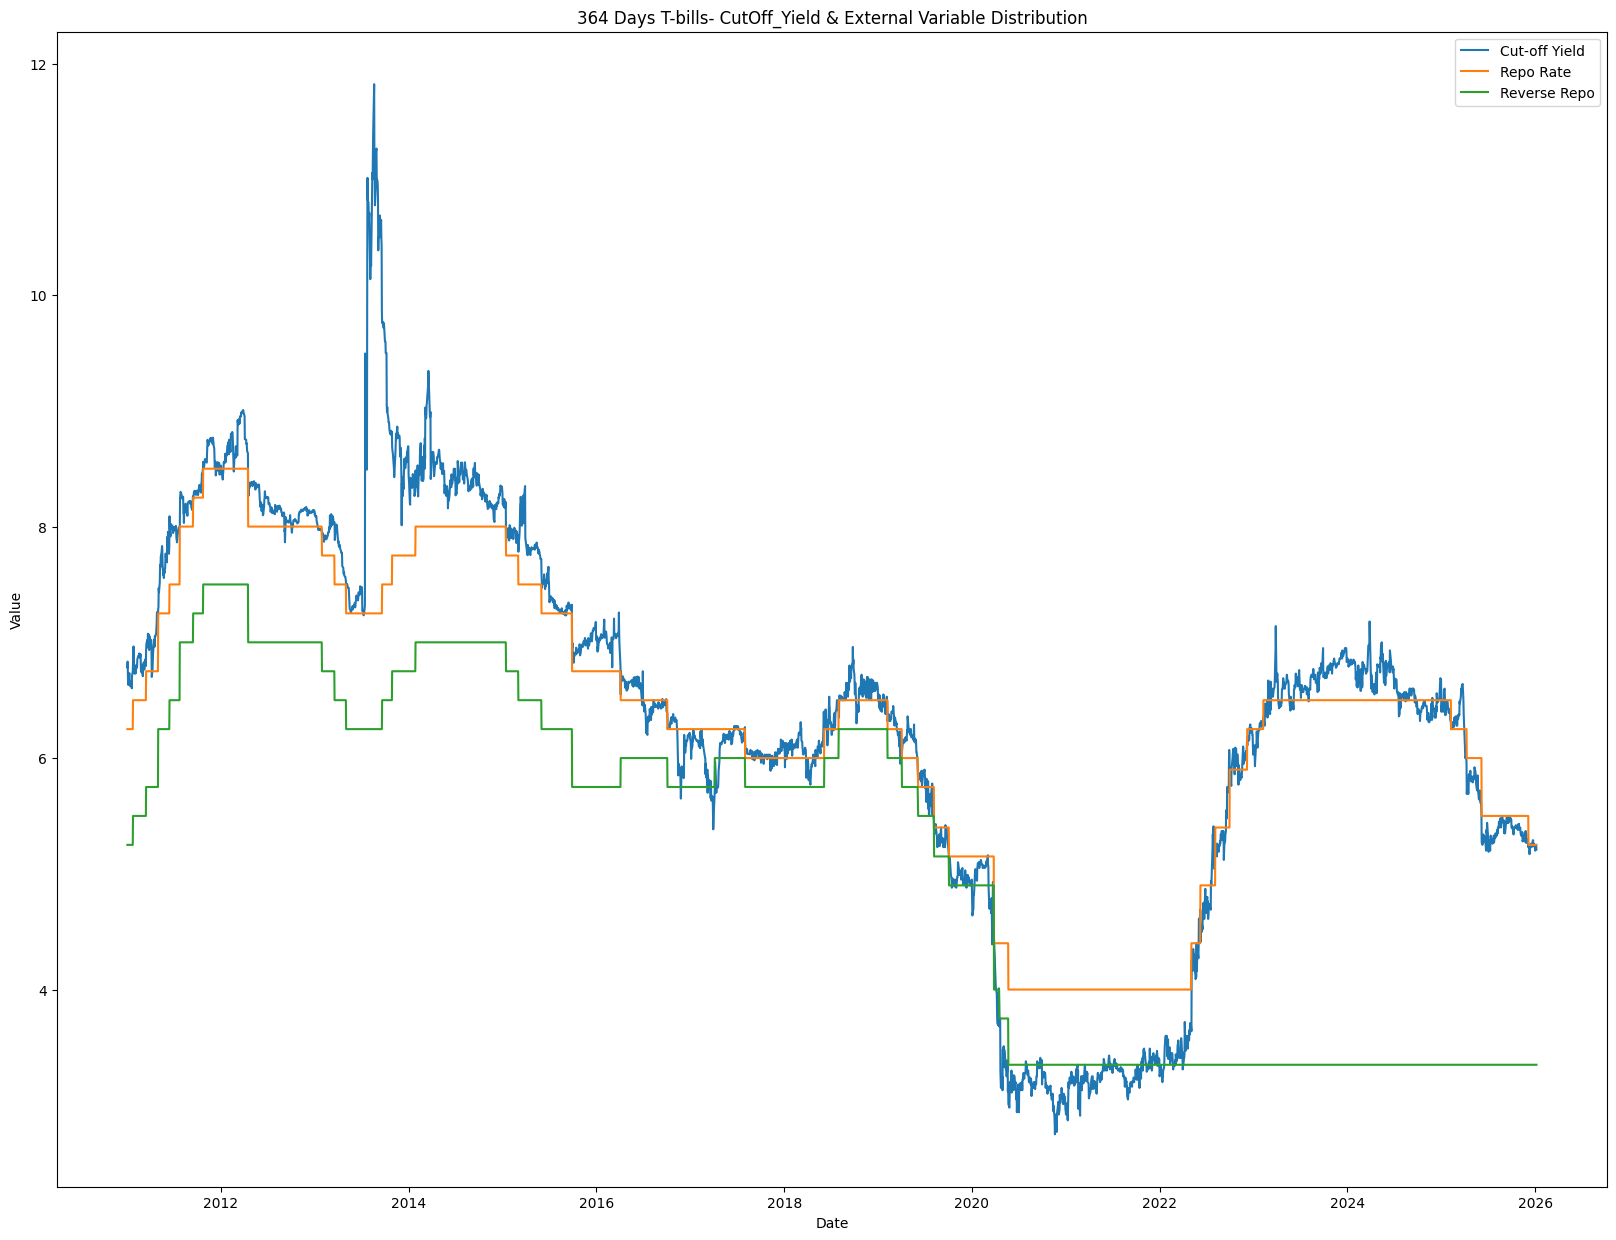

In [117]:
plt.figure(figsize=(20, 15))
plt.plot(dfs['Date'], dfs[['CutOff_Yield','Repo','Reverse Repo']])
#plt.plot(dfs['Date'], dfs['CPI Inflation']*0.010)
plt.title("364 Days T-bills- CutOff_Yield & External Variable Distribution")
plt.legend(['Cut-off Yield', 'Repo Rate', 'Reverse Repo'])
plt.xlabel('Date')
plt.ylabel('Value')
plt.show()

### AUTO-ARIMA FORECASTING 

In [118]:
from pmdarima import auto_arima
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [119]:
data= dfs.set_index('Date')
data.tail(3)

,CutOff_Yield,Year,Fed_Reserve_Rate,Bank Rate,Repo,Reverse Repo,Standing Deposit Facility Rate,Marginal Standing Facility Rate,Cash Reserve Ratio,Statutory Liquidity Ratio,Net Liquidity,Overnight Repo Cut off,Overnight Rev Repo Cut off,Term Repo Cut off,Term Rev Repo Cut off,CPI Inflation,USDINR,foreign_exc_resrv,call_money_avg
Date,,,,,,,,,,,,,,,,,,,
2026-01-03,5.25,2026,3.75,5.5,5.25,3.35,5.0,5.5,3.0,18.0,-872423.0,5.26,5.49,5.26,5.24,197.9,90.1242,61553630.0,5.45
2026-01-04,5.25,2026,3.75,5.5,5.25,3.35,5.0,5.5,3.0,18.0,-872423.0,5.26,5.49,5.26,5.24,197.9,90.1242,61553630.0,5.45
2026-01-05,5.21,2026,3.75,5.5,5.25,3.35,5.0,5.5,3.0,18.0,-872423.0,5.26,5.49,5.26,5.24,197.9,90.2729,61553630.0,5.45


In [120]:
df1= dfs.set_index('Date')

In [121]:
data.columns

Index(['CutOff_Yield', 'Year', 'Fed_Reserve_Rate', 'Bank Rate', 'Repo',
       'Reverse Repo', 'Standing Deposit Facility Rate',
       'Marginal Standing Facility Rate', 'Cash Reserve Ratio',
       'Statutory Liquidity Ratio', 'Net Liquidity', 'Overnight Repo Cut off',
       'Overnight Rev Repo Cut off', 'Term Repo Cut off',
       'Term Rev Repo Cut off', 'CPI Inflation', 'USDINR', 'foreign_exc_resrv',
       'call_money_avg'],
      dtype='object')

In [122]:
# removing some unwanted columns
data= data.drop(['Bank Rate'], axis=1)
data.head(3)

,CutOff_Yield,Year,Fed_Reserve_Rate,Repo,Reverse Repo,Standing Deposit Facility Rate,Marginal Standing Facility Rate,Cash Reserve Ratio,Statutory Liquidity Ratio,Net Liquidity,Overnight Repo Cut off,Overnight Rev Repo Cut off,Term Repo Cut off,Term Rev Repo Cut off,CPI Inflation,USDINR,foreign_exc_resrv,call_money_avg
Date,,,,,,,,,,,,,,,,,,
2011-01-03,6.7844,2011,0.5,6.25,5.25,3.75,8.25,6.0,24.0,1170340.0,8.01,7.99,8.8,7.99,89.5,44.67,13749360.0,6.58
2011-01-04,6.8333,2011,0.5,6.25,5.25,3.75,8.25,6.0,24.0,1170340.0,8.01,7.99,8.8,7.99,89.5,44.84,13749360.0,6.58
2011-01-05,6.7071,2011,0.5,6.25,5.25,3.75,8.25,6.0,24.0,1170340.0,8.01,7.99,8.8,7.99,89.5,45.20,13749360.0,6.58


In [ ]:
## Since we are forecasting daily data, i'm forward filling the daily date and avoid nulls 

datas= data.resample('D').ffill()
datas= datas[datas.index >='2021-01-01']
datas= datas.ffill()
datas.tail(3)

,CutOff_Yield,Year,Fed_Reserve_Rate,Repo,Reverse Repo,Standing Deposit Facility Rate,Marginal Standing Facility Rate,Cash Reserve Ratio,Statutory Liquidity Ratio,Net Liquidity,Overnight Repo Cut off,Overnight Rev Repo Cut off,Term Repo Cut off,Term Rev Repo Cut off,CPI Inflation,USDINR,foreign_exc_resrv,call_money_avg
Date,,,,,,,,,,,,,,,,,,
2026-01-03,5.25,2026,3.75,5.25,3.35,5.0,5.5,3.0,18.0,-872423.0,5.26,5.49,5.26,5.24,197.9,90.1242,61553630.0,5.45
2026-01-04,5.25,2026,3.75,5.25,3.35,5.0,5.5,3.0,18.0,-872423.0,5.26,5.49,5.26,5.24,197.9,90.1242,61553630.0,5.45
2026-01-05,5.21,2026,3.75,5.25,3.35,5.0,5.5,3.0,18.0,-872423.0,5.26,5.49,5.26,5.24,197.9,90.2729,61553630.0,5.45


In [124]:
# getting the month and day of the year columns
import pandas as pd
import calendar
def create_feature(df):
    df.index = pd.to_datetime(df.index)
    df['quarter']=df.index.quarter
    df['Month']=df.index.month
    #df['Year']=df.index.year
    df['dayofyear']=df.index.dayofyear
    # df['weekday']=df.index.dayofweek
    return df
# d.index.dayofweek #0=Monday , 1=Tuesday , 2=Wednesday
 
def encode_quarter_finQuarter(data):
    data.loc[data['quarter']==1,'quarter']='Q4'
    data.loc[data['quarter']==2,'quarter']='Q1'
    data.loc[data['quarter']==3,'quarter']='Q2'
    data.loc[data['quarter']==4,'quarter']='Q3'
    return data
def encode_finQuarter_num(data):
    data.loc[data['quarter']=='Q4','quarter']=4
    data.loc[data['quarter']=='Q1','quarter']=1
    data.loc[data['quarter']=='Q2','quarter']=2
    data.loc[data['quarter']=='Q3','quarter']=3
    return data

def Merging_feature_engg_with_data(h23):
    h23=create_feature(h23)
    h23=encode_quarter_finQuarter(h23)
    h23=encode_finQuarter_num(h23)
    h23['quarter']=h23['quarter'].astype('int')
    return h23

datas =Merging_feature_engg_with_data(datas)
datas= datas.ffill()
datas.tail(4)



C:\Users\manirathinams\AppData\Local\Temp\ipykernel_5060\3998805701.py:15: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Q4' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  data.loc[data['quarter']==1,'quarter']='Q4'


,CutOff_Yield,Year,Fed_Reserve_Rate,Repo,Reverse Repo,Standing Deposit Facility Rate,Marginal Standing Facility Rate,Cash Reserve Ratio,Statutory Liquidity Ratio,Net Liquidity,...,Overnight Rev Repo Cut off,Term Repo Cut off,Term Rev Repo Cut off,CPI Inflation,USDINR,foreign_exc_resrv,call_money_avg,quarter,Month,dayofyear
Date,,,,,,,,,,,,,,,,,,,,,
2026-01-02,5.25,2026,3.75,5.25,3.35,5.0,5.5,3.0,18.0,-872423.0,...,5.49,5.26,5.24,197.9,90.1242,61553630.0,5.45,4,1,2
2026-01-03,5.25,2026,3.75,5.25,3.35,5.0,5.5,3.0,18.0,-872423.0,...,5.49,5.26,5.24,197.9,90.1242,61553630.0,5.45,4,1,3
2026-01-04,5.25,2026,3.75,5.25,3.35,5.0,5.5,3.0,18.0,-872423.0,...,5.49,5.26,5.24,197.9,90.1242,61553630.0,5.45,4,1,4
2026-01-05,5.21,2026,3.75,5.25,3.35,5.0,5.5,3.0,18.0,-872423.0,...,5.49,5.26,5.24,197.9,90.2729,61553630.0,5.45,4,1,5


## Modify

In [41]:
# This code is useful for backtesting, To run forecasting upto particular date

#data= data[data.index <='2024-05-31']
#data.tail()

### Performing Dickey-Fuller Test

To check data is stationary or non stationary

In [126]:
from statsmodels.tsa.stattools import adfuller

# Perform the ADF test
def adf_test(timeseries):
    # Perform Dickey-Fuller test:
    adf_result = adfuller(timeseries, autolag='AIC')
    
    # Print ADF test results
    print('ADF Statistic: {:.4f}'.format(adf_result[0]))
    print('p-value: {:.4f}'.format(adf_result[1]))
    print('Critical Values:')
    for key, value in adf_result[4].items():
        print('\t{}: {:.4f}'.format(key, value))

# Assuming 'Yield' column is the one you want to test for stationarity
adf_test(datas['CutOff_Yield'])

ADF Statistic: -1.8461
p-value: 0.3578
Critical Values:
	1%: -3.4339
	5%: -2.8631
	10%: -2.5676


The p-value 0.5158 is greater than 0.05 for a significance level of 5%, indicating rejects the H1-(alternate hypothesis) and accepting the H0-(null hypothesis). Therefore, the data is likely non-stationary. it might require differencing or other transformations to achieve stationarity.

### Finding the difference in D value

In [127]:
# Assuming 'Yield' column is the one you want to test for stationarity, considering d value as 1
adf_test(datas['CutOff_Yield'].diff()[1:])

ADF Statistic: -25.6278
p-value: 0.0000
Critical Values:
	1%: -3.4339
	5%: -2.8631
	10%: -2.5676


### Seasonality and Trend Chart

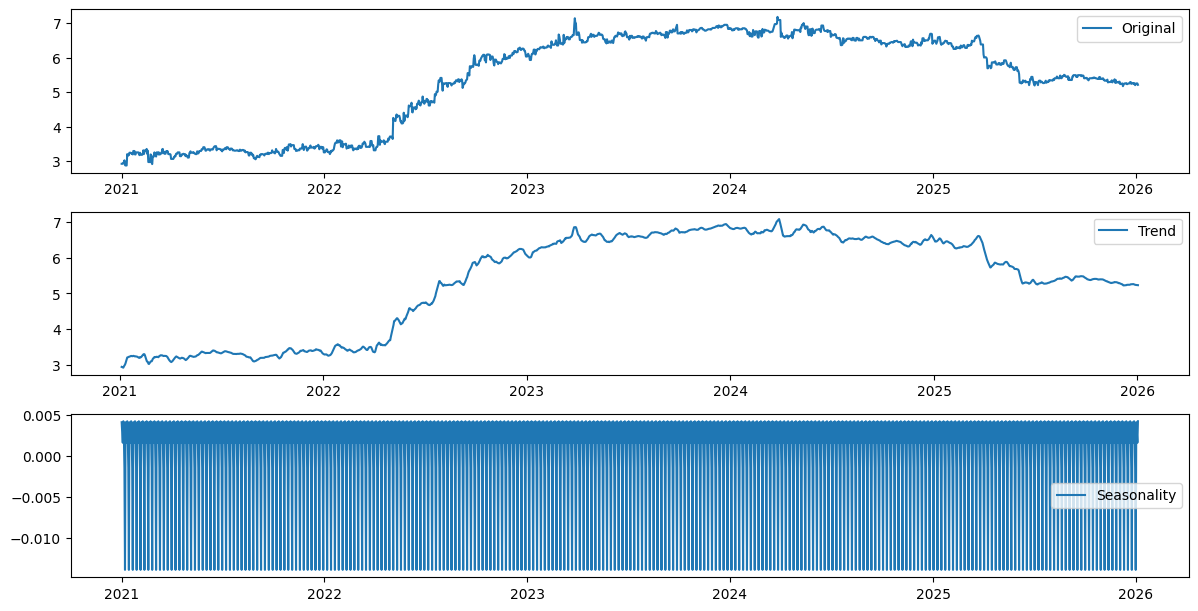

In [128]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Perform seasonal decomposition
result = seasonal_decompose(datas['CutOff_Yield'], model='additive', period=7)  # Assuming weekly seasonality repeats every 52 weeks

# Plot the components
plt.figure(figsize=(12, 8))

plt.subplot(411)
plt.plot(datas.index, datas['CutOff_Yield'], label='Original')
plt.legend(loc='best')

plt.subplot(412)
plt.plot(result.trend, label='Trend')
plt.legend(loc='best')

plt.subplot(413)
plt.plot(result.seasonal, label='Seasonality')
plt.legend(loc='best')

plt.tight_layout()
plt.show()

In [129]:
datas.columns

Index(['CutOff_Yield', 'Year', 'Fed_Reserve_Rate', 'Repo', 'Reverse Repo',
       'Standing Deposit Facility Rate', 'Marginal Standing Facility Rate',
       'Cash Reserve Ratio', 'Statutory Liquidity Ratio', 'Net Liquidity',
       'Overnight Repo Cut off', 'Overnight Rev Repo Cut off',
       'Term Repo Cut off', 'Term Rev Repo Cut off', 'CPI Inflation', 'USDINR',
       'foreign_exc_resrv', 'call_money_avg', 'quarter', 'Month', 'dayofyear'],
      dtype='object')

In [130]:
#Applying the standard scaler function to particular columns to make all columns in same scale
from sklearn.preprocessing import StandardScaler

scaler= StandardScaler()

# Applying the standard scaler function to Net Liquidity column
datas['Net Liquidity'] = scaler.fit_transform(datas[['Net Liquidity']])
datas['CPI Inflation'] = scaler.fit_transform(datas[['CPI Inflation']])
datas['USDINR'] = scaler.fit_transform(datas[['USDINR']])
datas['foreign_exc_resrv'] = scaler.fit_transform(datas[['foreign_exc_resrv']])
datas['call_money_avg'] = scaler.fit_transform(datas[['call_money_avg']])
#df_scaled = pd.DataFrame(scaler.fit_transform(final), columns=final.columns)
datas.head(3)

,CutOff_Yield,Year,Fed_Reserve_Rate,Repo,Reverse Repo,Standing Deposit Facility Rate,Marginal Standing Facility Rate,Cash Reserve Ratio,Statutory Liquidity Ratio,Net Liquidity,...,Overnight Rev Repo Cut off,Term Repo Cut off,Term Rev Repo Cut off,CPI Inflation,USDINR,foreign_exc_resrv,call_money_avg,quarter,Month,dayofyear
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-01,2.92,2021,0.25,4.0,3.35,3.75,4.25,3.0,18.0,-3.552395,...,5.0,4.4,4.39,-1.868325,-1.596007,-1.331576,-1.508909,4,1,1
2021-01-02,2.92,2021,0.25,4.0,3.35,3.75,4.25,3.0,18.0,-3.552395,...,5.0,4.4,4.39,-1.868325,-1.596007,-1.331576,-1.508909,4,1,2
2021-01-03,2.92,2021,0.25,4.0,3.35,3.75,4.25,3.0,18.0,-3.552395,...,5.0,4.4,4.39,-1.868325,-1.596007,-1.331576,-1.508909,4,1,3


In [132]:
exog_cols = ['Repo', 'Reverse Repo','Fed_Reserve_Rate', 'Standing Deposit Facility Rate',
             'Marginal Standing Facility Rate', 'Cash Reserve Ratio',
             'Statutory Liquidity Ratio', 'Net Liquidity', 'Overnight Repo Cut off',
              'Overnight Rev Repo Cut off', 'Term Repo Cut off', 'Term Rev Repo Cut off','CPI Inflation', 'USDINR',
              'foreign_exc_resrv', 'call_money_avg', 'quarter','Month','dayofyear']

# Fit Auto ARIMA model
model = auto_arima(datas['CutOff_Yield'], exogenous=datas[exog_cols], d=1, m=7, stepwise=True, test='adf',trace=True) #test='adf'


d:\ML_Proj\PDF_ChatBot-using_GeminiPro\vevn\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\ML_Proj\PDF_ChatBot-using_GeminiPro\vevn\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\ML_Proj\PDF_ChatBot-using_GeminiPro\vevn\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\ML_Proj\PDF_ChatBot-using_GeminiPro\vevn\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[7] intercept   : AIC=-5142.169, Time=3.44 sec
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=-5085.757, Time=0.20 sec


d:\ML_Proj\PDF_ChatBot-using_GeminiPro\vevn\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\ML_Proj\PDF_ChatBot-using_GeminiPro\vevn\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=-5129.869, Time=0.57 sec


d:\ML_Proj\PDF_ChatBot-using_GeminiPro\vevn\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=-5135.728, Time=0.80 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=-5086.967, Time=0.05 sec


d:\ML_Proj\PDF_ChatBot-using_GeminiPro\vevn\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\ML_Proj\PDF_ChatBot-using_GeminiPro\vevn\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(2,1,2)(0,0,1)[7] intercept   : AIC=-5142.693, Time=2.66 sec


d:\ML_Proj\PDF_ChatBot-using_GeminiPro\vevn\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(2,1,2)(0,0,0)[7] intercept   : AIC=-5142.017, Time=1.95 sec


d:\ML_Proj\PDF_ChatBot-using_GeminiPro\vevn\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(2,1,2)(0,0,2)[7] intercept   : AIC=-5144.190, Time=3.28 sec


d:\ML_Proj\PDF_ChatBot-using_GeminiPro\vevn\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(2,1,2)(1,0,2)[7] intercept   : AIC=-5142.007, Time=6.39 sec


d:\ML_Proj\PDF_ChatBot-using_GeminiPro\vevn\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(1,1,2)(0,0,2)[7] intercept   : AIC=-5145.394, Time=2.81 sec


d:\ML_Proj\PDF_ChatBot-using_GeminiPro\vevn\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(1,1,2)(0,0,1)[7] intercept   : AIC=-5143.928, Time=2.27 sec


d:\ML_Proj\PDF_ChatBot-using_GeminiPro\vevn\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(1,1,2)(1,0,2)[7] intercept   : AIC=-5143.170, Time=5.22 sec


d:\ML_Proj\PDF_ChatBot-using_GeminiPro\vevn\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(1,1,2)(1,0,1)[7] intercept   : AIC=-5164.540, Time=3.75 sec


d:\ML_Proj\PDF_ChatBot-using_GeminiPro\vevn\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(1,1,2)(1,0,0)[7] intercept   : AIC=-5144.171, Time=1.20 sec


d:\ML_Proj\PDF_ChatBot-using_GeminiPro\vevn\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(1,1,2)(2,0,1)[7] intercept   : AIC=-5143.569, Time=3.46 sec


d:\ML_Proj\PDF_ChatBot-using_GeminiPro\vevn\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(1,1,2)(0,0,0)[7] intercept   : AIC=-5143.229, Time=1.22 sec


d:\ML_Proj\PDF_ChatBot-using_GeminiPro\vevn\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(1,1,2)(2,0,0)[7] intercept   : AIC=-5145.659, Time=1.40 sec


d:\ML_Proj\PDF_ChatBot-using_GeminiPro\vevn\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(1,1,2)(2,0,2)[7] intercept   : AIC=-5165.560, Time=5.44 sec


d:\ML_Proj\PDF_ChatBot-using_GeminiPro\vevn\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(0,1,2)(2,0,2)[7] intercept   : AIC=inf, Time=6.40 sec


d:\ML_Proj\PDF_ChatBot-using_GeminiPro\vevn\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(1,1,1)(2,0,2)[7] intercept   : AIC=-5161.288, Time=4.82 sec


d:\ML_Proj\PDF_ChatBot-using_GeminiPro\vevn\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(2,1,2)(2,0,2)[7] intercept   : AIC=-5160.691, Time=6.96 sec


d:\ML_Proj\PDF_ChatBot-using_GeminiPro\vevn\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(1,1,3)(2,0,2)[7] intercept   : AIC=-5166.628, Time=8.42 sec


d:\ML_Proj\PDF_ChatBot-using_GeminiPro\vevn\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(1,1,3)(1,0,2)[7] intercept   : AIC=-5144.384, Time=4.54 sec


d:\ML_Proj\PDF_ChatBot-using_GeminiPro\vevn\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(1,1,3)(2,0,1)[7] intercept   : AIC=-5144.825, Time=3.02 sec


d:\ML_Proj\PDF_ChatBot-using_GeminiPro\vevn\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(1,1,3)(1,0,1)[7] intercept   : AIC=-5154.034, Time=3.91 sec


d:\ML_Proj\PDF_ChatBot-using_GeminiPro\vevn\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(0,1,3)(2,0,2)[7] intercept   : AIC=inf, Time=7.45 sec


d:\ML_Proj\PDF_ChatBot-using_GeminiPro\vevn\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(2,1,3)(2,0,2)[7] intercept   : AIC=-5168.906, Time=8.09 sec


d:\ML_Proj\PDF_ChatBot-using_GeminiPro\vevn\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(2,1,3)(1,0,2)[7] intercept   : AIC=-5148.532, Time=7.72 sec


d:\ML_Proj\PDF_ChatBot-using_GeminiPro\vevn\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(2,1,3)(2,0,1)[7] intercept   : AIC=-5149.380, Time=5.97 sec


d:\ML_Proj\PDF_ChatBot-using_GeminiPro\vevn\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(2,1,3)(1,0,1)[7] intercept   : AIC=-5148.598, Time=3.93 sec


d:\ML_Proj\PDF_ChatBot-using_GeminiPro\vevn\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(3,1,3)(2,0,2)[7] intercept   : AIC=-5159.088, Time=9.28 sec


d:\ML_Proj\PDF_ChatBot-using_GeminiPro\vevn\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(2,1,4)(2,0,2)[7] intercept   : AIC=-5169.671, Time=9.44 sec


d:\ML_Proj\PDF_ChatBot-using_GeminiPro\vevn\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(2,1,4)(1,0,2)[7] intercept   : AIC=-5147.483, Time=7.97 sec


d:\ML_Proj\PDF_ChatBot-using_GeminiPro\vevn\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(2,1,4)(2,0,1)[7] intercept   : AIC=-5148.994, Time=6.88 sec


d:\ML_Proj\PDF_ChatBot-using_GeminiPro\vevn\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(2,1,4)(1,0,1)[7] intercept   : AIC=-5154.202, Time=5.13 sec


d:\ML_Proj\PDF_ChatBot-using_GeminiPro\vevn\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(1,1,4)(2,0,2)[7] intercept   : AIC=-5162.454, Time=9.61 sec


d:\ML_Proj\PDF_ChatBot-using_GeminiPro\vevn\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(3,1,4)(2,0,2)[7] intercept   : AIC=-5160.777, Time=11.26 sec


d:\ML_Proj\PDF_ChatBot-using_GeminiPro\vevn\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(2,1,5)(2,0,2)[7] intercept   : AIC=-5154.250, Time=12.88 sec


d:\ML_Proj\PDF_ChatBot-using_GeminiPro\vevn\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(1,1,5)(2,0,2)[7] intercept   : AIC=-5168.520, Time=12.48 sec


d:\ML_Proj\PDF_ChatBot-using_GeminiPro\vevn\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(3,1,5)(2,0,2)[7] intercept   : AIC=-5159.253, Time=11.27 sec


d:\ML_Proj\PDF_ChatBot-using_GeminiPro\vevn\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(2,1,4)(2,0,2)[7]             : AIC=inf, Time=6.11 sec

Best model:  ARIMA(2,1,4)(2,0,2)[7] intercept
Total fit time: 219.673 seconds


In [133]:
# Print model summary
print(model.summary())

                                       SARIMAX Results                                        
Dep. Variable:                                      y   No. Observations:                 1831
Model:             SARIMAX(2, 1, 4)x(2, 0, [1, 2], 7)   Log Likelihood                2596.836
Date:                                Wed, 07 Jan 2026   AIC                          -5169.671
Time:                                        16:36:19   BIC                          -5103.527
Sample:                                    01-01-2021   HQIC                         -5145.275
                                         - 01-05-2026                                         
Covariance Type:                                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept    8.24e-05      0.000      0.565      0.572      -0.000       0.000
ar.

In [134]:
# Predicting the next exogenous variable to forecast the cut-off yields
def Future_independet_Variables(h24):
    Future_Date = pd.date_range(start=h24.index[-1], periods=32, freq='D')
    Future_Date=Future_Date[1:]
    Future=pd.DataFrame({"Date":Future_Date})
    Future=Future.set_index("Date")
    Future['Repo']=h24['Repo'][-1]
    Future['Reverse Repo']=h24['Reverse Repo'][-1]
    Future['Fed_Reserve_Rate']=h24['Fed_Reserve_Rate'][-1]
    Future['Standing Deposit Facility Rate']=h24['Standing Deposit Facility Rate'][-1]
    Future['Marginal Standing Facility Rate']=h24['Marginal Standing Facility Rate'][-1]
    Future['Cash Reserve Ratio']=h24['Cash Reserve Ratio'][-1]
    Future['Statutory Liquidity Ratio']=h24['Statutory Liquidity Ratio'][-1]
    Future['Net Liquidity']=h24['Net Liquidity'][-1]
    Future['Overnight Repo Cut off']=h24['Overnight Repo Cut off'][-1]
    Future['Overnight Rev Repo Cut off']=h24['Overnight Rev Repo Cut off'][-1]
    Future['Term Repo Cut off']=h24['Term Repo Cut off'][-1]
    Future['Term Rev Repo Cut off']=h24['Term Rev Repo Cut off'][-1]
    Future['CPI Inflation']=h24['CPI Inflation'][-1]
    Future['USDINR']=h24['USDINR'][-1] 
    Future['foreign_exc_resrv']=h24['foreign_exc_resrv'][-1] 
    Future['call_money_avg']=h24['call_money_avg'][-1]   

    
    Future= Merging_feature_engg_with_data(Future)
    return Future

future_exog= Future_independet_Variables(datas)

C:\Users\manirathinams\AppData\Local\Temp\ipykernel_5060\4159783887.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Future['Repo']=h24['Repo'][-1]
C:\Users\manirathinams\AppData\Local\Temp\ipykernel_5060\4159783887.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Future['Reverse Repo']=h24['Reverse Repo'][-1]
C:\Users\manirathinams\AppData\Local\Temp\ipykernel_5060\4159783887.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`


In [135]:
# Get forecast
#forecast_steps = 26  # Number of steps to forecast into the future
#forecast = model.predict(n_periods=forecast_steps)
forecast, conf_int = model.predict(n_periods=len(future_exog), X= future_exog, return_conf_int=True)

d:\ML_Proj\PDF_ChatBot-using_GeminiPro\vevn\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\ML_Proj\PDF_ChatBot-using_GeminiPro\vevn\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [138]:
result= forecast.to_frame(name='forecasted')
result

,forecasted
2026-01-06,5.206231
2026-01-07,5.211497
2026-01-08,5.211318
2026-01-09,5.217553
2026-01-10,5.215668
2026-01-11,5.214178
2026-01-12,5.213177
2026-01-13,5.212460
2026-01-14,5.212972
2026-01-15,5.208036


## ------------ End ---------------

### Model Evaluation code

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

rmse=np.sqrt(mean_squared_error(final['CutOff_Yield'], final['Forecasted']))
mae= mean_absolute_error(final['CutOff_Yield'], final['Forecasted'])
print(f'RMSE score:{rmse}')
print(f'MAE score:{mae}')

In [ ]:
plt.figure(figsize=(15, 8))
plt.plot(final.index, final[['CutOff_Yield', 'Forecasted']])
plt.title("364 Days T-bills- CutOff_Yield vs Forecasted")
plt.legend(['CutOff_Yield', 'Forecasted'])
plt.xlabel('Date')
plt.ylabel('Value')
plt.show()

In [ ]:
filename='D:\TASK\CP rates\Repo_external.xlsx'
df.to_excel(filename, index=False)
print('saved successfully')